In [2]:
import pandas as pd

In [3]:
loso_metrics = pd.read_csv('loso_fold_metrics.csv')
subjects_info = pd.read_csv('subject_info.csv')
subjects_info.columns = subjects_info.columns.str.strip().str.capitalize().str.replace('_', ' ')  # Eliminar espacios en los nombres de las columnas

metrics = pd.merge(loso_metrics, subjects_info, left_on='patient', right_on='Patient id')
metrics = metrics.rename(columns={'patient': 'Patient'}, inplace=False)  # Renombrar la columna 'Patient id' a 'Patient_id'
metrics.head()

,model,Patient,Accuracy,Precision,Recall,F1 Score,F1 Macro,F1 Micro,ROC AUC,Patient id,Age years,Gender,Seizure,Localization,Lateralization,Eeg channel,Number seizures,Rec time minutes
0,Chronos2,PN00,0.817204,0.500000,0.137255,0.215385,0.555968,0.817204,0.733660,PN00,55,Male,IAS,T,R,29,5,198
1,Moirai2,PN00,0.813620,0.461538,0.117647,0.187500,0.541118,0.813620,0.733058,PN00,55,Male,IAS,T,R,29,5,198
2,TSMixer (Google-style),PN00,0.810036,0.458333,0.215686,0.293333,0.591801,0.810036,0.658841,PN00,55,Male,IAS,T,R,29,5,198
3,TabPFN,PN00,0.899642,0.925926,0.490196,0.641026,0.791346,0.899642,0.863519,PN00,55,Male,IAS,T,R,29,5,198
4,TabICL,PN00,0.881720,0.680000,0.666667,0.673267,0.800529,0.881720,0.861154,PN00,55,Male,IAS,T,R,29,5,198


In [8]:
import math
import matplotlib.pyplot as plt


def plot_grid(df, plots, ncols=2, figsize_per_plot=(6, 5), plot_path=None):
    """
    Plot a grid of barplots and scatterplots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    plots : list of dict
        Each dict defines one subplot.

        Barplot example:
        {
            'type': 'bar',
            'x': 'Gender',
            'y': 'F1 Macro'
        }

        Scatterplot example:
        {
            'type': 'scatter',
            'x': 'Age',
            'y': 'F1 Macro'
        }

    ncols : int
        Number of subplot columns.

    figsize_per_plot : tuple
        Size (width, height) per subplot.
    """

    nplots = len(plots)
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            figsize_per_plot[0] * ncols,
            figsize_per_plot[1] * nrows
        )
    )

    # Normalize axes structure
    if nplots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, plot_cfg in zip(axes, plots):

        plot_type = plot_cfg['type']
        x_col = plot_cfg['x']
        y_col = plot_cfg['y']

        # =========================
        # BARPLOT
        # =========================
        if plot_type == 'bar':

            summary = (
                df.groupby(x_col, as_index=False)[y_col]
                .agg(mean='mean', std='std')
                .fillna(0)
            )

            ax.bar(
                summary[x_col],
                summary['mean'],
                yerr=summary['std'],
                capsize=6,
                color='steelblue',
                edgecolor='navy',
                alpha=0.7,
                error_kw={
                    'elinewidth': 1.5,
                    'ecolor': 'black',
                    'capthick': 1.5
                }
            )

            ax.set_title(
                f'{y_col} by {x_col}',
                fontsize=13,
                fontweight='bold'
            )

            ax.grid(axis='y', alpha=0.3, linestyle='--')

        # =========================
        # SCATTERPLOT
        # =========================
        elif plot_type == 'scatter':

            ax.scatter(
                df[x_col],
                df[y_col],
                color='steelblue',
                edgecolor='navy',
                alpha=0.7,
                s=80
            )

            ax.set_title(
                f'{y_col} vs {x_col}',
                fontsize=13,
                fontweight='bold'
            )

            ax.grid(alpha=0.3, linestyle='--')

        else:
            raise ValueError(
                f"Unsupported plot type: {plot_type}"
            )

        ax.set_xlabel(x_col, fontsize=11, fontweight='bold')
        ax.set_ylabel(y_col, fontsize=11, fontweight='bold')

        ax.tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for i in range(nplots, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=400)
    plt.show()


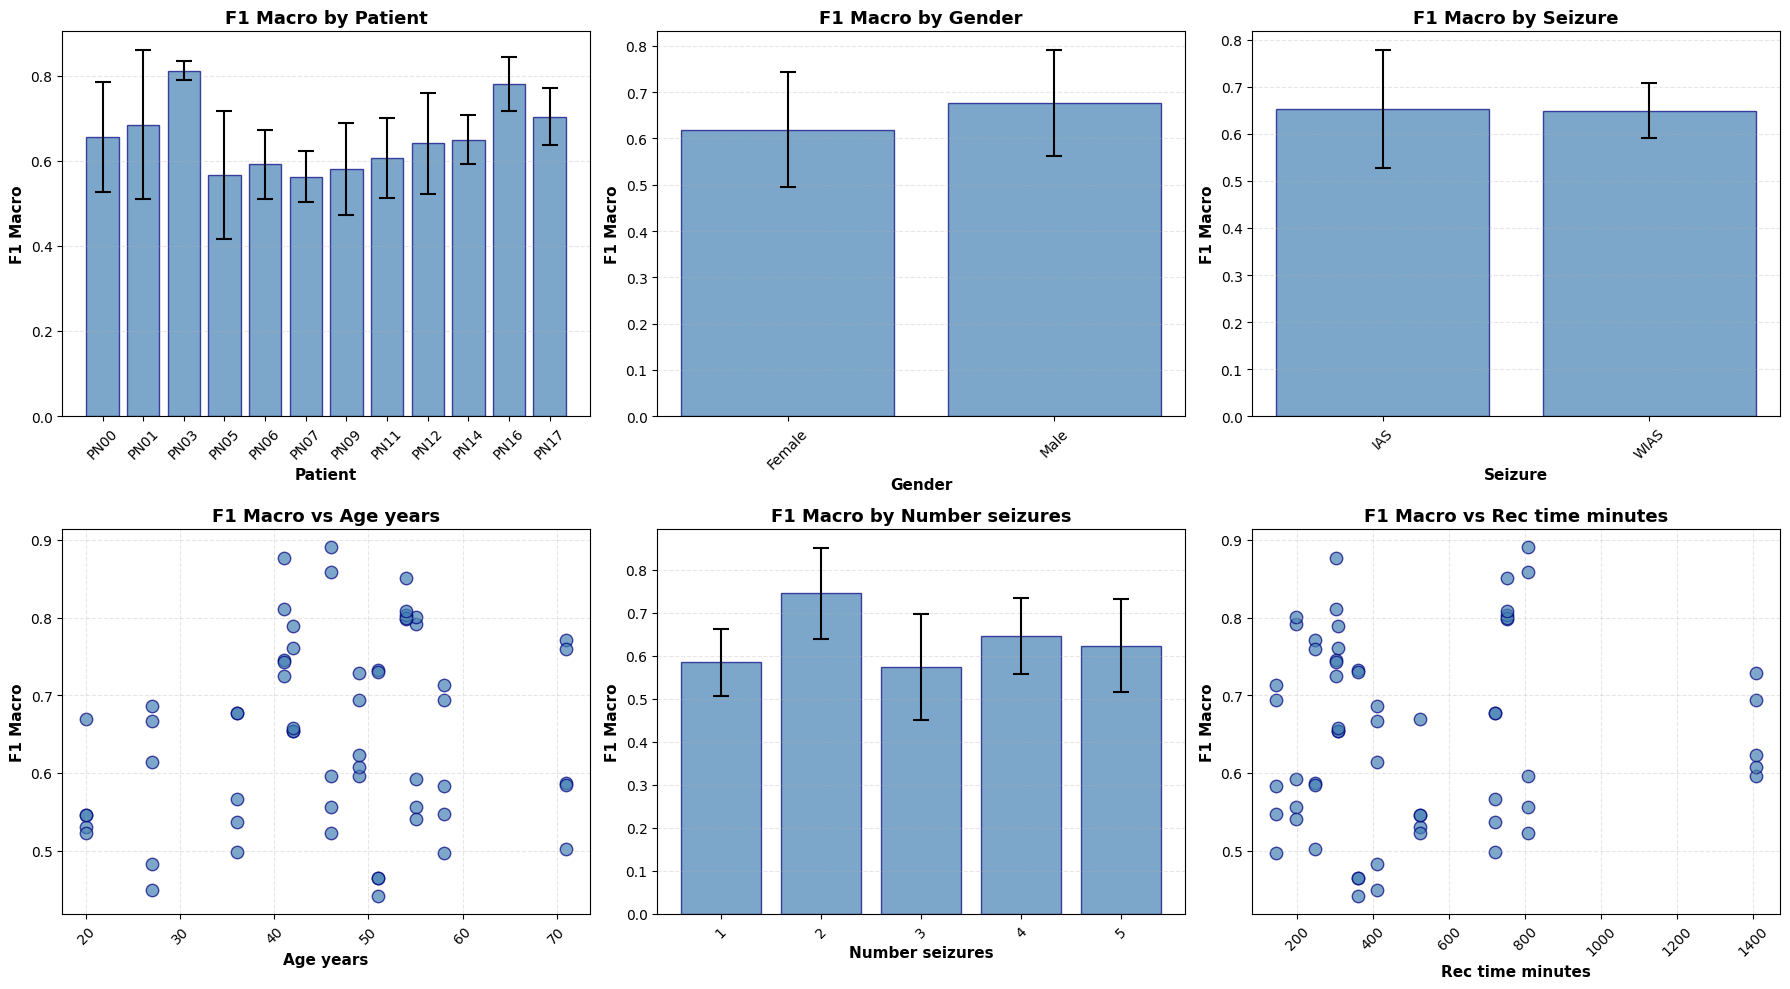

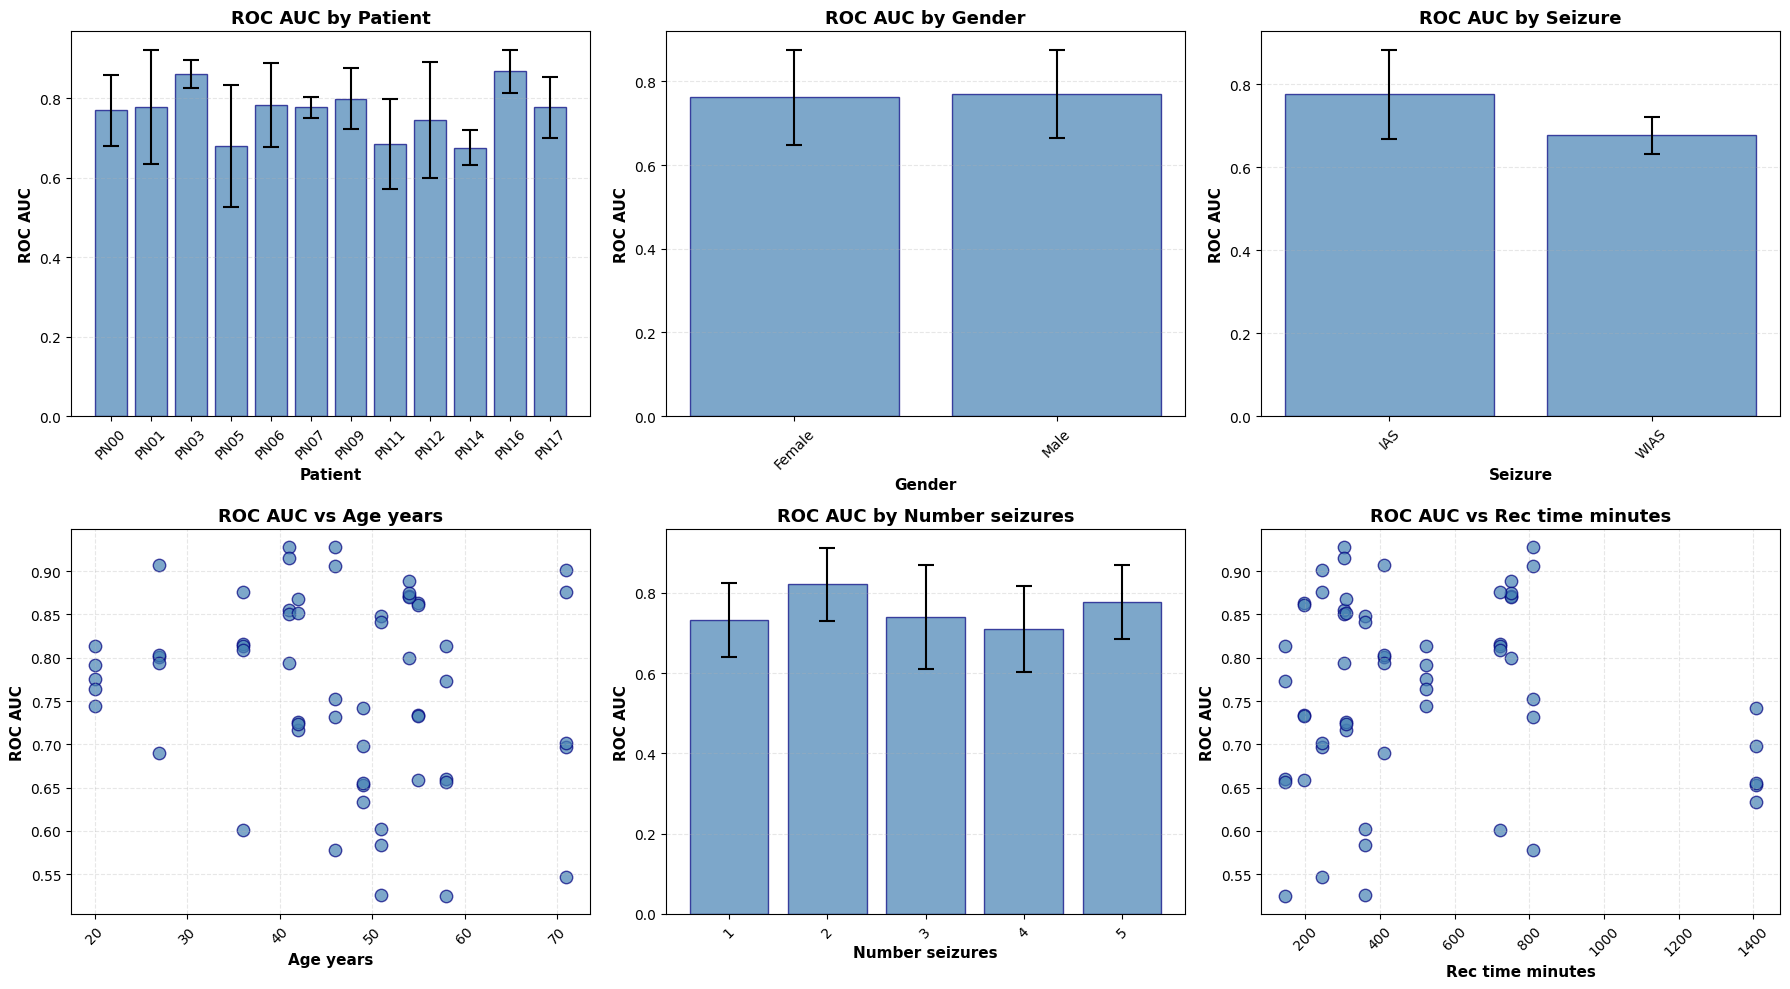

In [ ]:
plot_grid(
    metrics,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Gender', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'F1 Macro'},
    ],
    ncols=3,
    plot_path='explainability/f1_macro_analysis_all.png'
)

plot_grid(
    metrics,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Gender', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'ROC AUC'},
    ],
    ncols=3,
    plot_path='explainability/roc_auc_analysis_all.png'
)

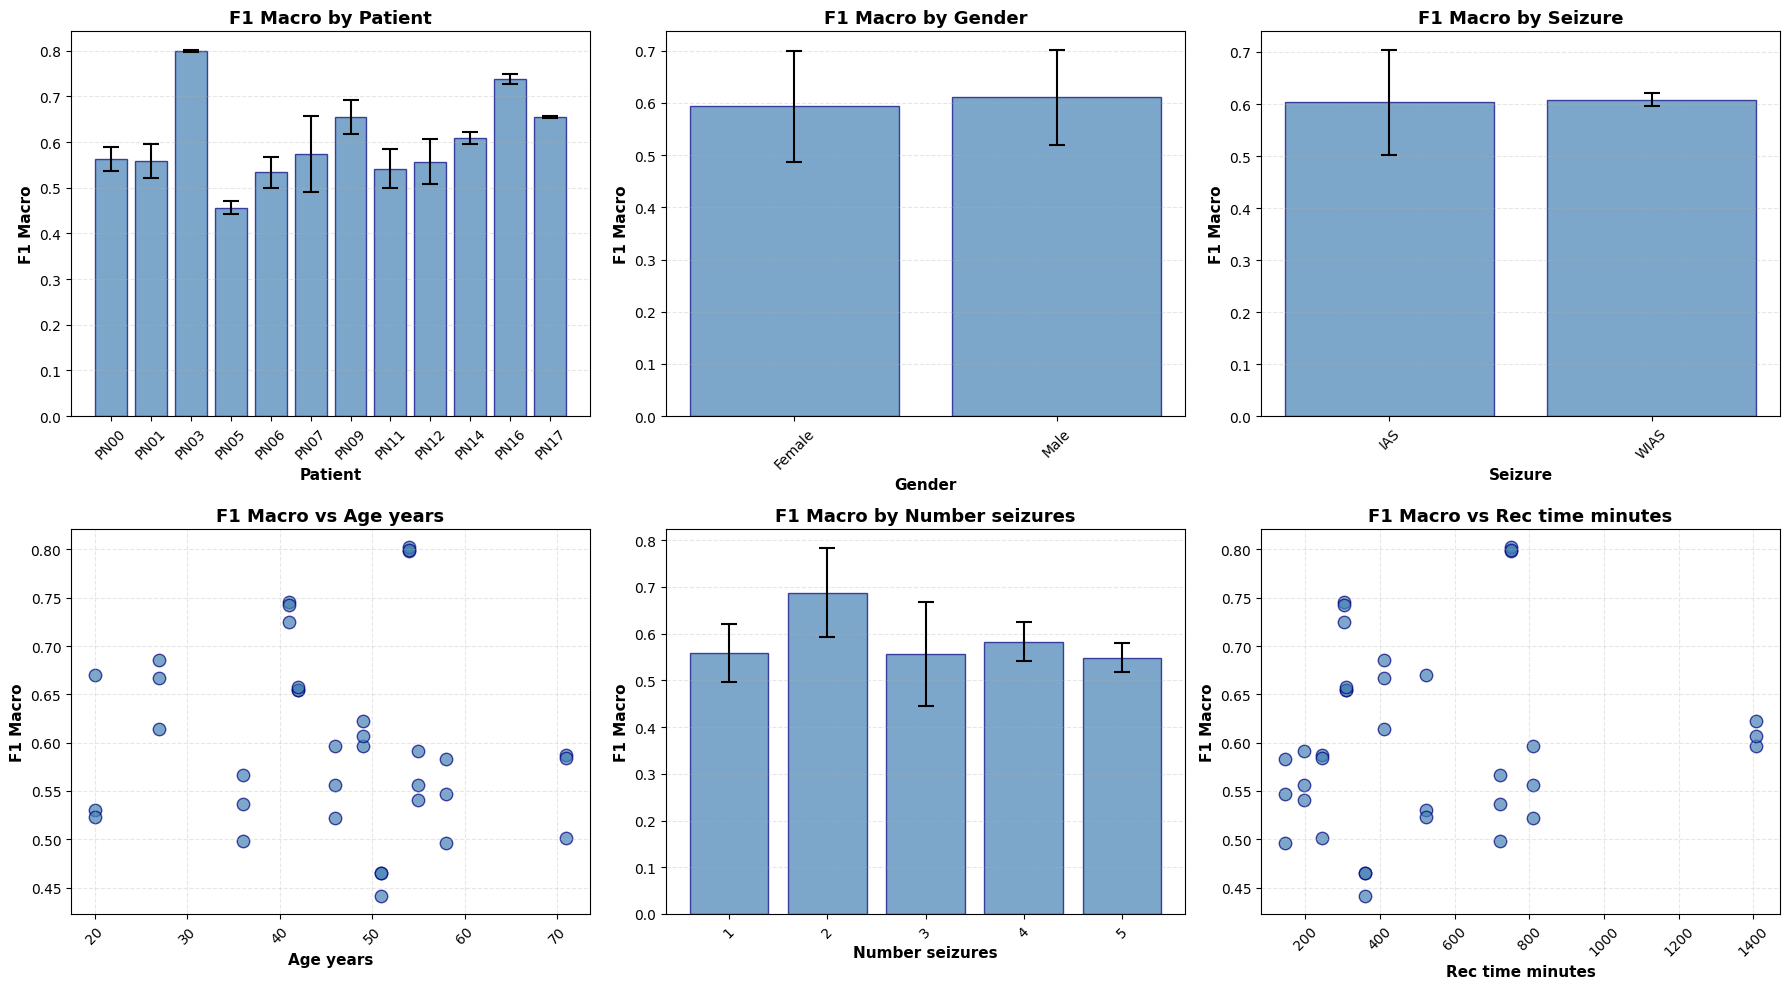

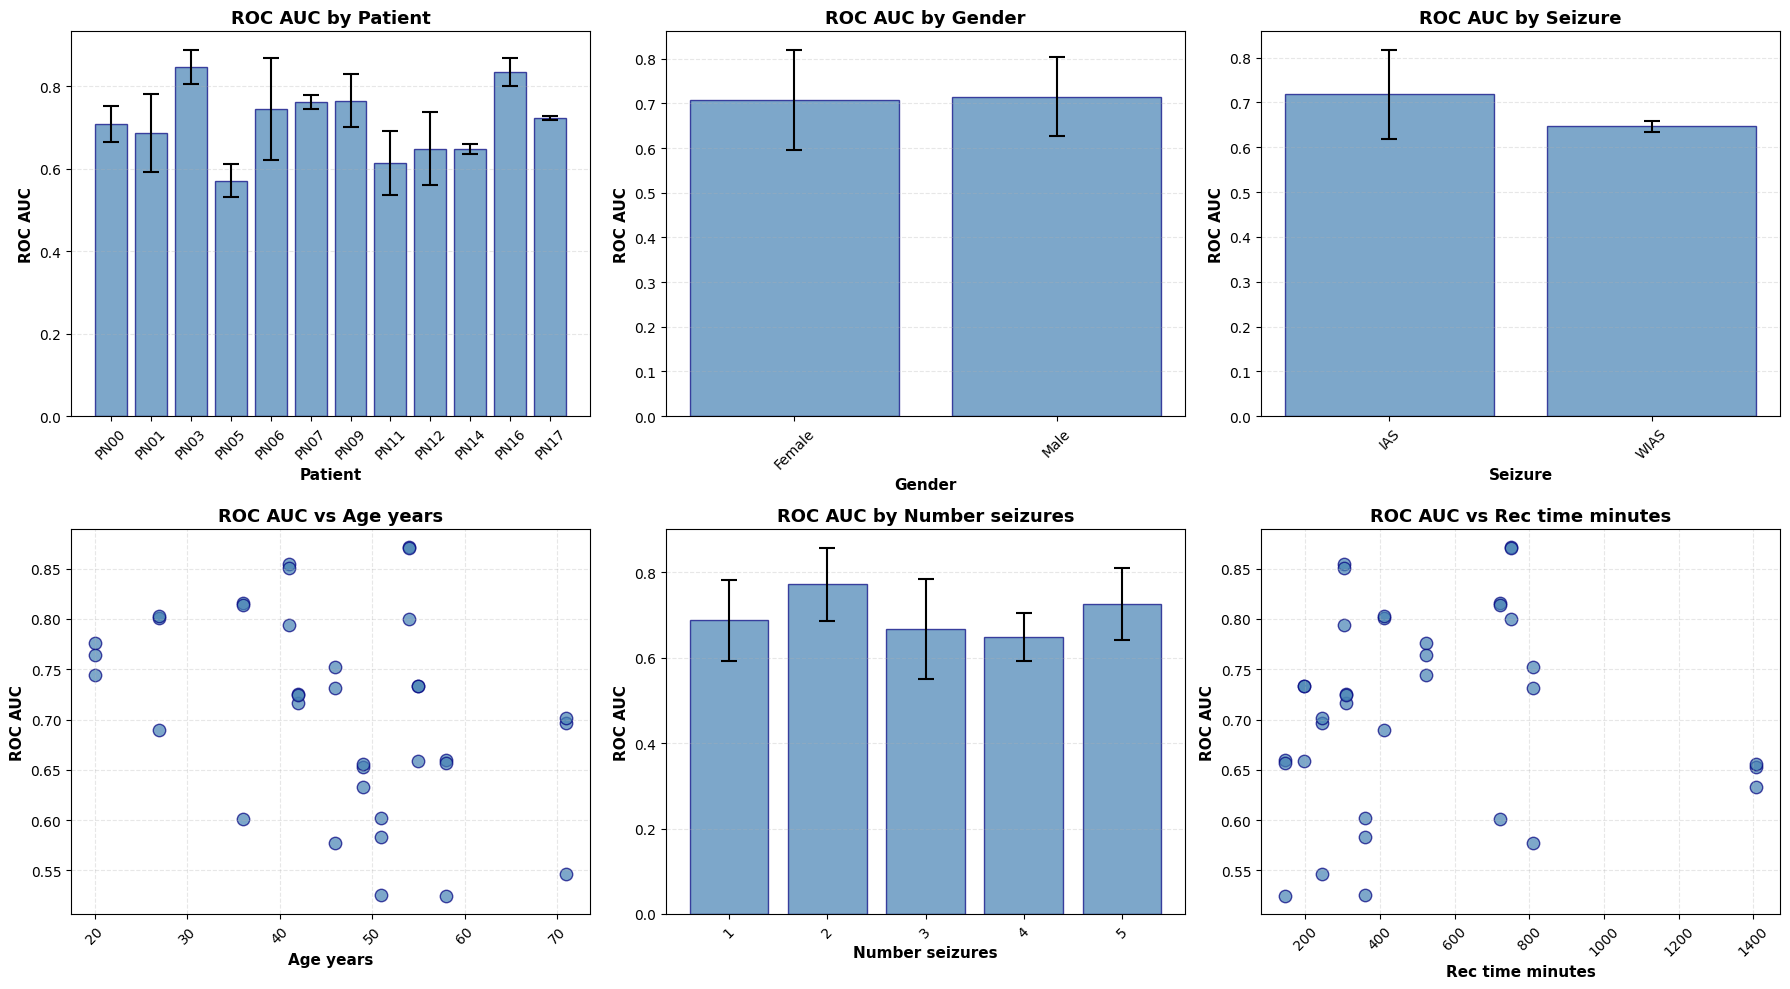

In [10]:


metrics_ts = metrics[metrics.model.isin(['Chronos2', 'Moirai2', 'TSMixer (Google-style)'])]
plot_grid(
    metrics_ts,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Gender', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'F1 Macro'},
    ],
    ncols=3,
    plot_path='explainability/f1_macro_analysis_ts.png'
)

plot_grid(
    metrics_ts,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Gender', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'ROC AUC'},
    ],
    ncols=3,
    plot_path='explainability/roc_auc_analysis_ts.png'
)

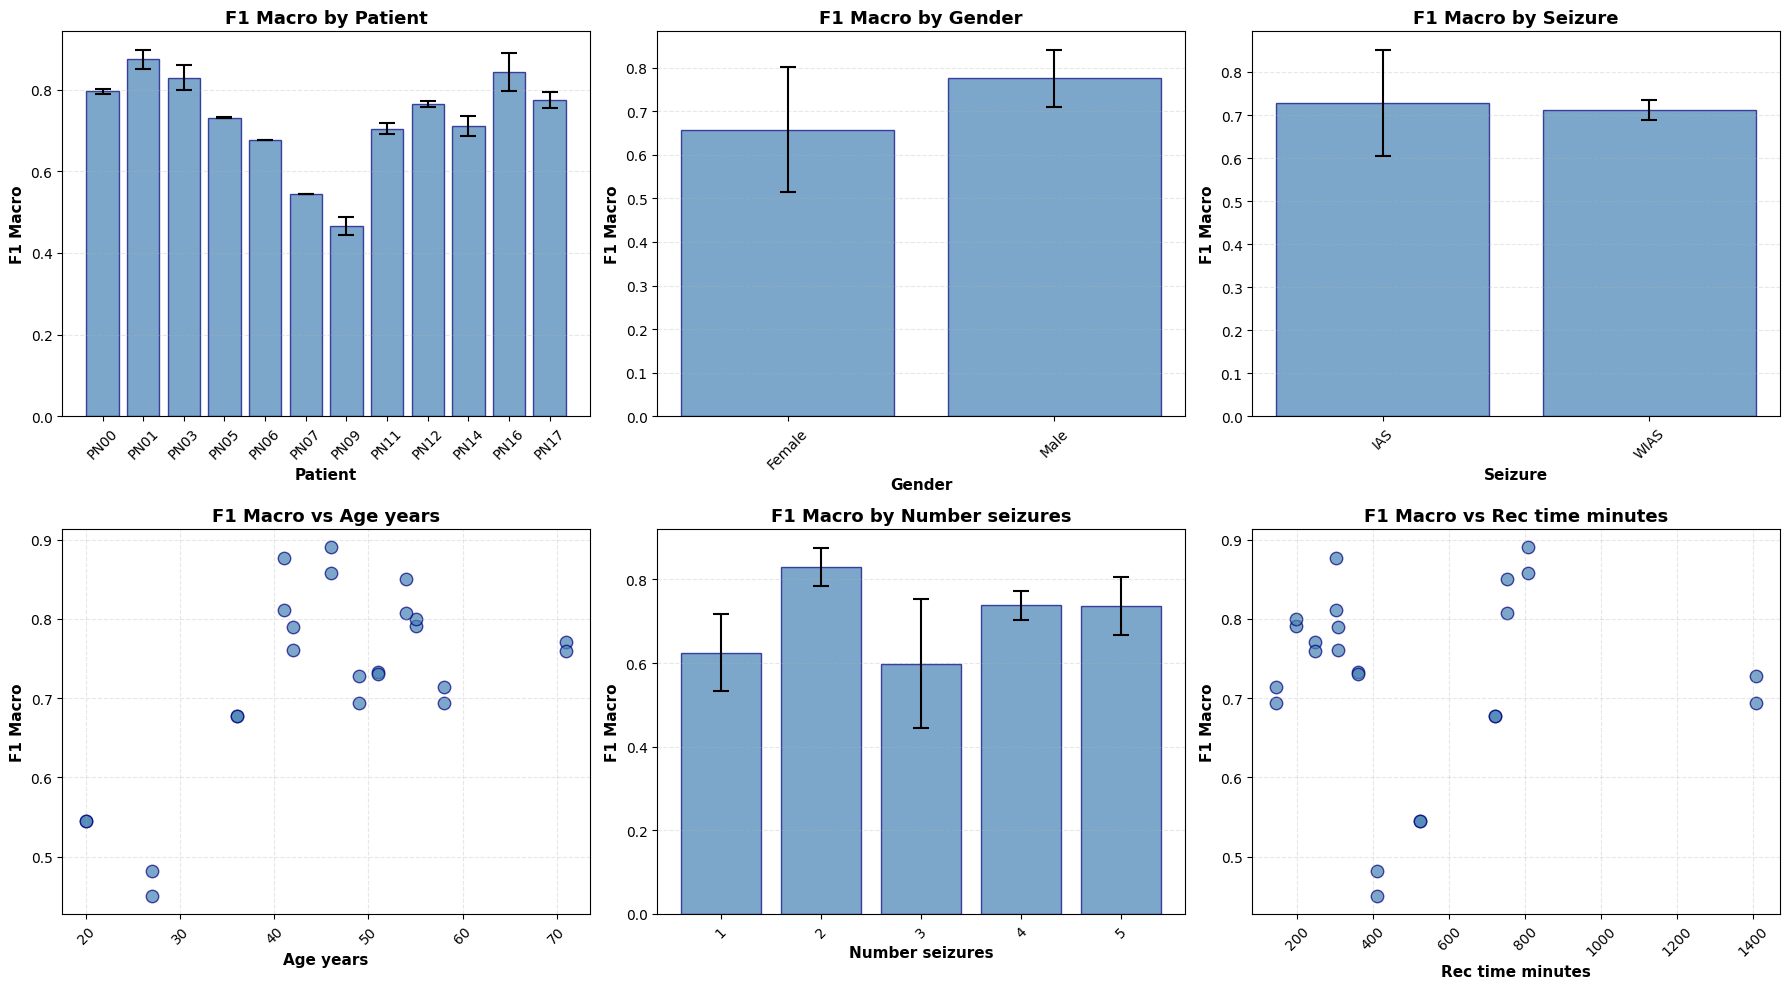

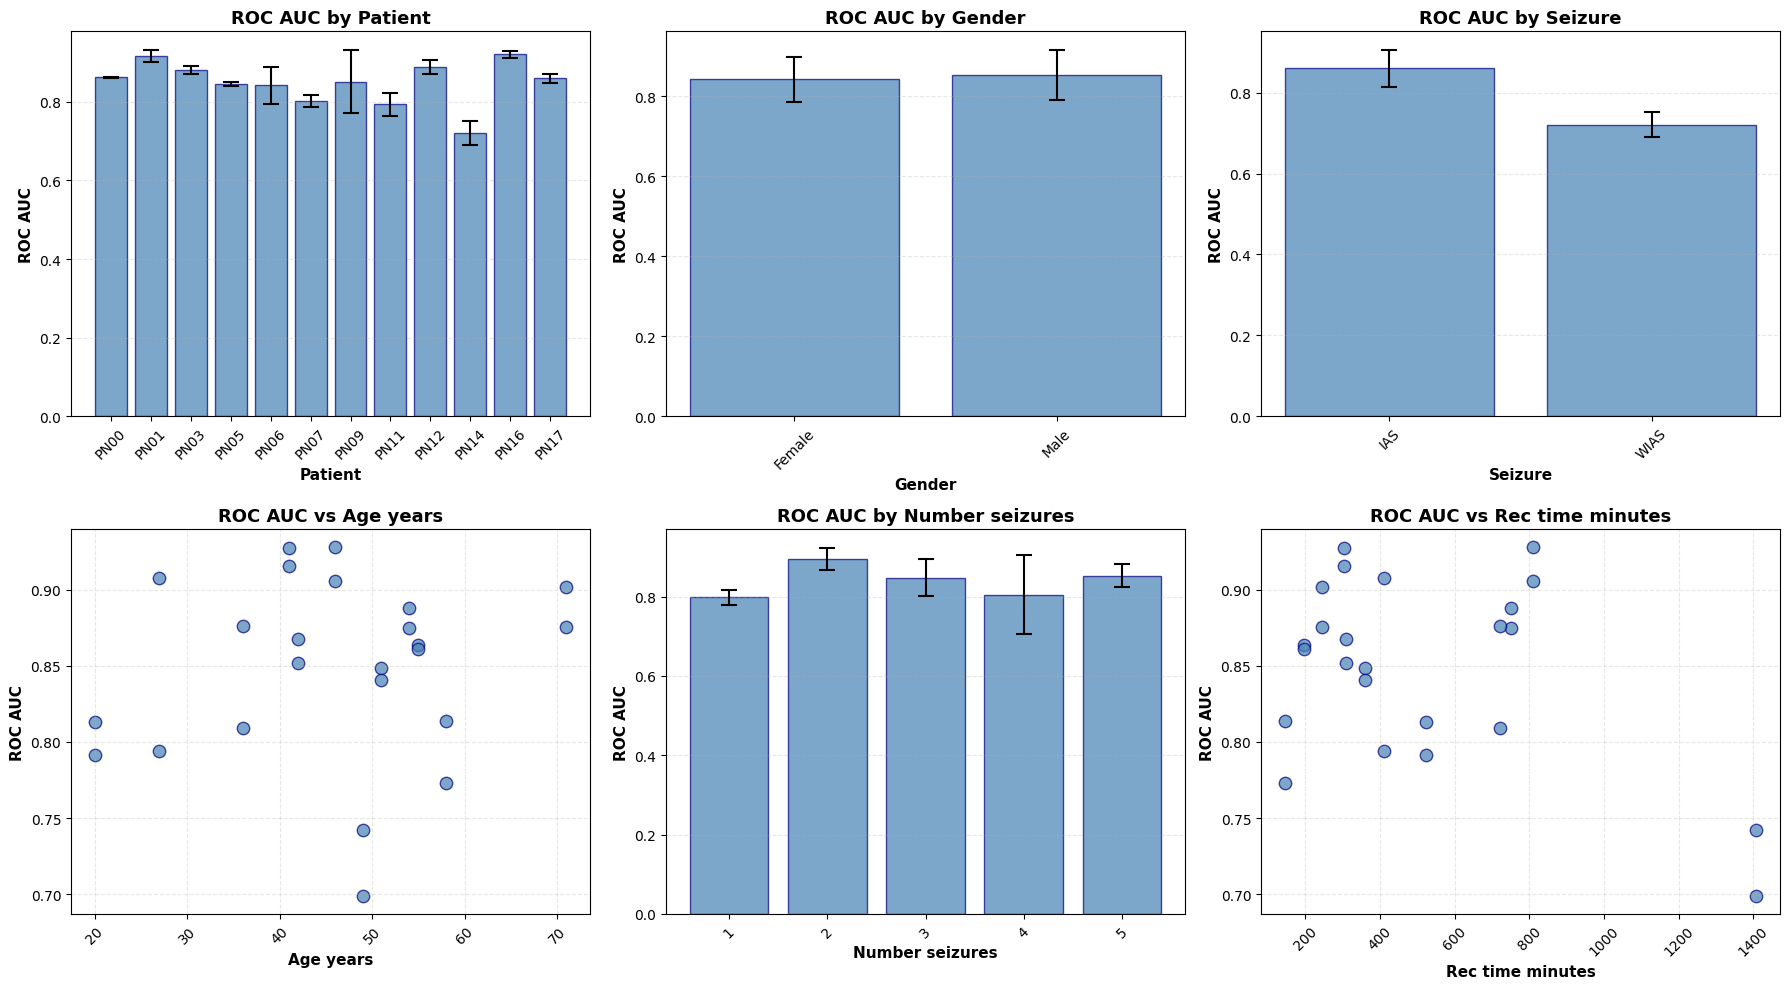

In [11]:

metrics_tab = metrics[metrics.model.isin(['TabPFN', 'TabICL'])]

plot_grid(
    metrics_tab,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Gender', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'F1 Macro'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'F1 Macro'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'F1 Macro'},
    ],
    ncols=3,
    plot_path='explainability/f1_macro_analysis_tabular.png'
)

plot_grid(
    metrics_tab,
    plots=[
        {'type': 'bar', 'x': 'Patient', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Gender', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Seizure', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Age years', 'y': 'ROC AUC'},
        {'type': 'bar', 'x': 'Number seizures', 'y': 'ROC AUC'},
        {'type': 'scatter', 'x': 'Rec time minutes', 'y': 'ROC AUC'},
    ],
    ncols=3,
    plot_path='explainability/roc_auc_analysis_tabular.png'
)